In [1]:
import pandas as pd
import os

os.chdir("/Users/rishwanthpb/MLOPS/MLOPS_PROJECT")

df = pd.read_parquet("data/raw/yellow_tripdata_2019-01.parquet")

print("Shape before cleaning:", df.shape)

# Fix 1 — Filter to only valid January 2019 dates
df = df[
    (df['tpep_pickup_datetime'] >= '2019-01-01') &
    (df['tpep_pickup_datetime'] < '2019-02-01')
]

# Fix 2 — Drop airport_fee (100% null in 2019)
df = df.drop(columns=['airport_fee'])

# Fix 3 — Fill congestion_surcharge nulls with 0
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)

# Fix 4 — Drop rows with null passenger_count
df = df.dropna(subset=['passenger_count', 'RatecodeID'])

print("Shape after cleaning:", df.shape)
print("\nDate range after fix:", df['tpep_pickup_datetime'].min(), "to", df['tpep_pickup_datetime'].max())
print("\nNull counts after fix:\n", df.isnull().sum())

Shape before cleaning: (7696617, 19)
Shape after cleaning: (7667408, 18)

Date range after fix: 2019-01-01 00:00:00 to 2019-01-31 23:59:58

Null counts after fix:
 VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
dtype: int64


In [2]:
# Engineer target variable — hourly demand per zone
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.floor('h')

demand = df.groupby(['PULocationID', 'pickup_hour']).size().reset_index(name='demand')

print("Demand table shape:", demand.shape)
print("\nSample demand rows:\n", demand.head(10))
print("\nDemand statistics:\n", demand['demand'].describe())

# Top 10 busiest zones
top_zones = demand.groupby('PULocationID')['demand'].mean().sort_values(ascending=False).head(10)
print("\nTop 10 busiest zones by average hourly demand:\n", top_zones)

Demand table shape: (102562, 3)

Sample demand rows:
    PULocationID         pickup_hour  demand
0             1 2019-01-01 02:00:00       1
1             1 2019-01-01 05:00:00       1
2             1 2019-01-01 06:00:00       1
3             1 2019-01-01 08:00:00       2
4             1 2019-01-01 10:00:00       4
5             1 2019-01-01 12:00:00       4
6             1 2019-01-01 13:00:00       1
7             1 2019-01-01 15:00:00       2
8             1 2019-01-01 17:00:00       1
9             1 2019-01-01 19:00:00       3

Demand statistics:
 count    102562.000000
mean         74.758761
std         143.357898
min           1.000000
25%           1.000000
50%           6.000000
75%          73.000000
max        1402.000000
Name: demand, dtype: float64

Top 10 busiest zones by average hourly demand:
 PULocationID
237    446.860215
236    434.149194
161    419.903226
162    372.563172
230    354.412634
186    350.436828
48     323.805108
170    321.220430
234    319.432796
142 

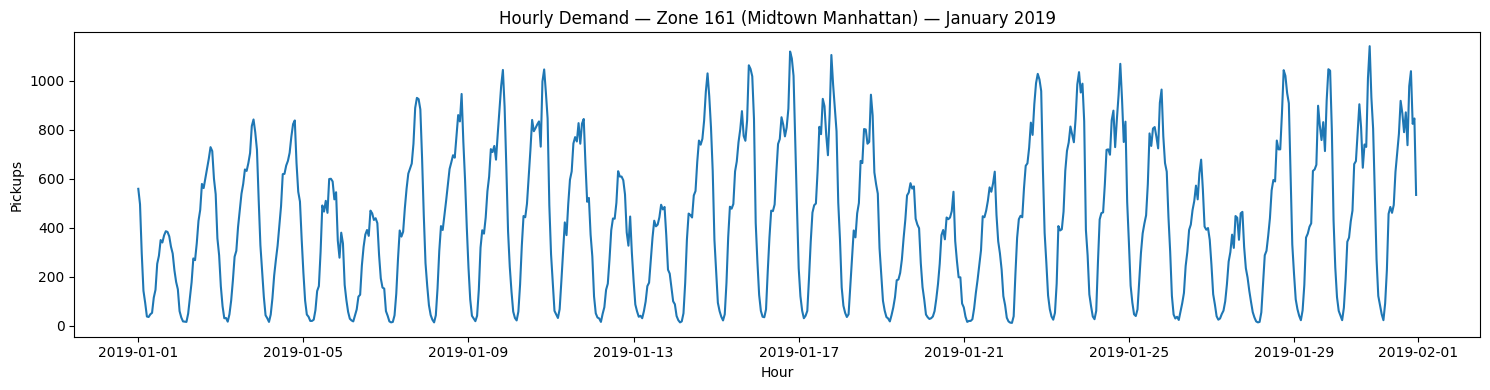

In [3]:
import matplotlib.pyplot as plt

# Pick zone 161 — Midtown Manhattan, typically the busiest
zone_161 = demand[demand['PULocationID'] == 161].copy()
zone_161 = zone_161.sort_values('pickup_hour')

plt.figure(figsize=(15, 4))
plt.plot(zone_161['pickup_hour'], zone_161['demand'])
plt.title('Hourly Demand — Zone 161 (Midtown Manhattan) — January 2019')
plt.xlabel('Hour')
plt.ylabel('Pickups')
plt.tight_layout()
plt.show()